# Part 1

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, RocCurveDisplay, classification_report
)

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/diabetes.csv')

In [ ]:
print(f'Shape: {df.shape}')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print(f'Missing values: \n\n{df.isna().sum()}')

Missing values: 

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [ ]:
features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[features] = df[features].replace({0 : np.nan})

In [ ]:
print(f'Missing values after replacing zeros with NaN: \n\n{df.isna().sum()}')

Missing values after replacing zeros with NaN: 

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
df[features] = df[features].fillna(df[features].median())

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.to_csv('cleaned_diabetes.csv', index=False)

In [ ]:
df_clean = pd.read_csv('/content/cleaned_diabetes.csv')
print(f'Total missing values (after imputation): {df.isna().sum().sum()}\nDuplicate rows: {df.duplicated().sum()}\ndf_clean shape: {df_clean.shape}\nSaved file: cleaned_diabetes.csv')

Total missing values (after imputation): 0
Duplicate rows: 0
df_clean shape: (768, 9)
Saved file: cleaned_diabetes.csv


In [ ]:
X = df.drop(columns=['Outcome'])
y = df_clean['Outcome']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (768, 8)
y shape: (768,)


# Part 2

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'Train set: {X_train.shape} | {y_train.shape}')
print(f'Test set: {X_test.shape} | {y_test.shape}')

Train set: (537, 8) | (537,)
Test set: (231, 8) | (231,)


In [ ]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

In [ ]:
lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)

In [ ]:
acc= accuracy_score(y_test, y_pred)
missc = 1 - acc
cm = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {acc}')
print(f'Misclassification rate (1 - accuracy): {missc}')
print(f'Confusion Matrix: \n{cm}')

cls_rep = classification_report(y_test, y_pred)
print(f'Classification Report: \n{cls_rep}')

Accuracy: 0.7445887445887446
Misclassification rate (1 - accuracy): 0.2554112554112554
Confusion Matrix: 
[[129  21]
 [ 38  43]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       150
           1       0.67      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.70      0.70       231
weighted avg       0.74      0.74      0.74       231



In [ ]:
TN , FP , FN , TP = cm.ravel()
metrics = {
    'TP' : TP ,
    'TN' : TN ,
    'FP' : FP ,
    'FN' : FN ,
    'TRP (recall)' : TP / (TP+ FN),
    'TNR (specificity)' : TN / (TN + FP),
    'FPR' : FP / (TN + FP),
    'FNR' : FN / (TP + FN),
    'Precision' : TP/(TP + FP)
}
metrics_df = pd.DataFrame(metrics.items(), columns=['Metric','Value'])
metrics_df

,Metric,Value
0,TP,43.000000
1,TN,129.000000
2,FP,21.000000
3,FN,38.000000
4,TRP (recall),0.530864
5,TNR (specificity),0.860000
6,FPR,0.140000
7,FNR,0.469136
8,Precision,0.671875


AUC: 0.8361316872427983


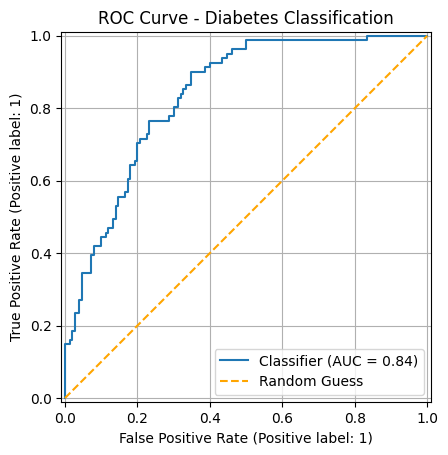

In [ ]:
y_proba  = lr_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred)
print(f'AUC: {auc}')

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], linestyle='--', color='orange', label='Random Guess')
plt.title("ROC Curve - Diabetes Classification")
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [ ]:
thresholds = [0.30, 0.50, 0.70]
summary = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t[0,0], cm_t[0,1], cm_t[1,0], cm_t[1,1]

    acc_t = accuracy_score(y_test, y_pred_t)
    prec_t = precision_score(y_test, y_pred_t, zero_division=0)
    rec_t = recall_score(y_test, y_pred_t, zero_division=0)

    specificity_t = tn / (tn + fp)
    fpr_t = fp / (fp + tn)
    fnr_t = fn / (fn + tp)

    summary.append({
        "threshold": t,
        "accuracy": acc_t,
        "precision": prec_t,
        "TPR_recall": rec_t,
        "TNR_specificity": specificity_t,
        "FPR": fpr_t,
        "FNR": fnr_t,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,threshold,accuracy,precision,TPR_recall,TNR_specificity,FPR,FNR,TP,TN,FP,FN
0,0.3,0.731602,0.590476,0.765432,0.713333,0.286667,0.234568,62,107,43,19
1,0.5,0.744589,0.671875,0.530864,0.860000,0.140000,0.469136,43,129,21,38
2,0.7,0.722944,0.717949,0.345679,0.926667,0.073333,0.654321,28,139,11,53


In [ ]:

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ["accuracy", "roc_auc"]

cv_scores = cross_validate(lr_pipeline, X, y, cv=cv, scoring=scoring)

accuracy_scores = cv_scores['test_accuracy']
roc_auc_scores = cv_scores['test_roc_auc']

print(f"10-Fold CV Accuracy: mean={accuracy_scores.mean():.4f}, std={accuracy_scores.std():.4f}")
print(f"10-Fold CV ROC-AUC : mean={roc_auc_scores.mean():.4f}, std={roc_auc_scores.std():.4f}")


10-Fold CV Accuracy: mean=0.7668, std=0.0251
10-Fold CV ROC-AUC : mean=0.8367, std=0.0496
